In [5]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math

In [6]:
df = pd.read_csv("batdongsan.com.vn.csv", dtype = {"month": "string" , "id" :
 "string"})
print("DONE")

DONE


In [7]:
df.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81163 entries, 0 to 81162
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         81163 non-null  string 
 1   month      81162 non-null  string 
 2   project    78097 non-null  str    
 3   investor   65453 non-null  str    
 4   square     81162 non-null  float64
 5   bedrooms   81162 non-null  float64
 6   bathrooms  81162 non-null  float64
 7   direction  51086 non-null  str    
 8   balcony    54426 non-null  str    
 9   district   81162 non-null  str    
 10  ward       79506 non-null  str    
 11  price      81162 non-null  float64
dtypes: float64(4), str(6), string(2)
memory usage: 7.4 MB


In [9]:
df.head()

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price
0,28086120,12,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0
1,28088954,12,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0
2,28097966,12,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0
3,27895887,12,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0
4,28056031,12,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0


In [10]:
df.describe()

,square,bedrooms,bathrooms,price
count,81162.000000,81162.000000,81162.000000,81162.000000
mean,83.481974,2.365602,1.897785,2404.748090
std,25.662160,0.622283,0.404293,1038.825418
min,7.000000,1.000000,1.000000,350.000000
25%,66.000000,2.000000,2.000000,1520.000000
50%,79.000000,2.000000,2.000000,2300.000000
75%,98.000000,3.000000,2.000000,3150.000000
max,296.000000,4.000000,4.000000,5000.000000


In [12]:
df.columns.tolist()

['id',
 'month',
 'project',
 'investor',
 'square',
 'bedrooms',
 'bathrooms',
 'direction',
 'balcony',
 'district',
 'ward',
 'price']

Các cột số: ['square', 'bedrooms', 'bathrooms', 'price', 'price_per_m2']


C:\Users\Admin\miniconda3\envs\ml_env\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\Admin\miniconda3\envs\ml_env\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\Admin\miniconda3\envs\ml_env\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\Admin\miniconda3\envs\ml_env\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\U

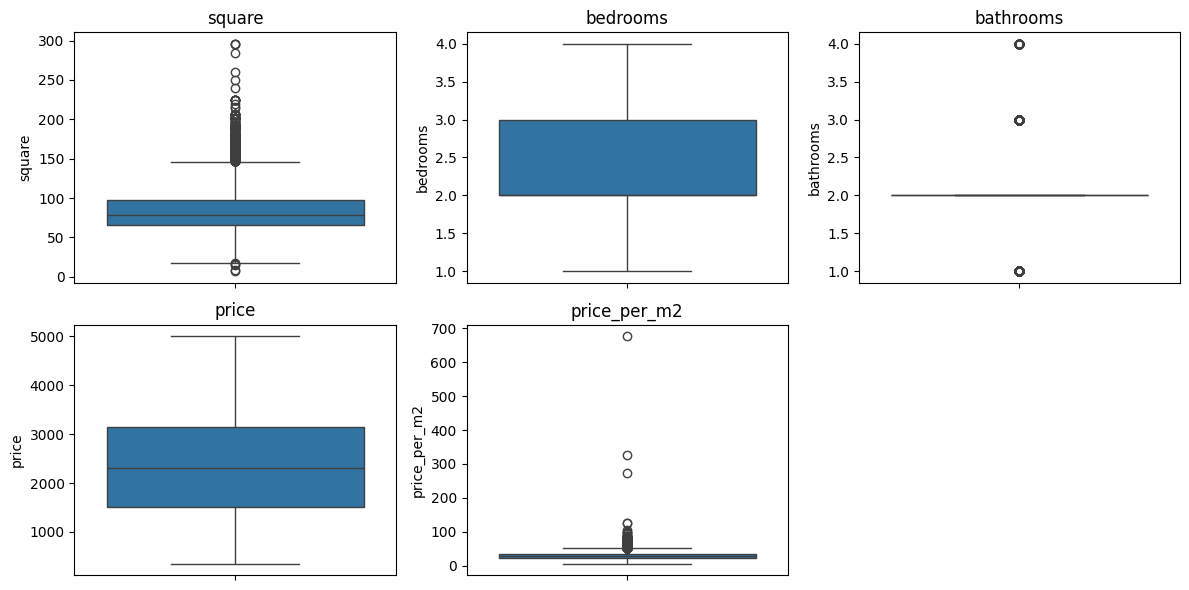

In [32]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Các cột số:", numeric_cols)

# Vẽ boxplot cho từng cột
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols[:6], 1):  # vẽ tối đa 6 cột
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, y=col, orientation='vertical')
    plt.title(col)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21828\4150411792.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment='right')


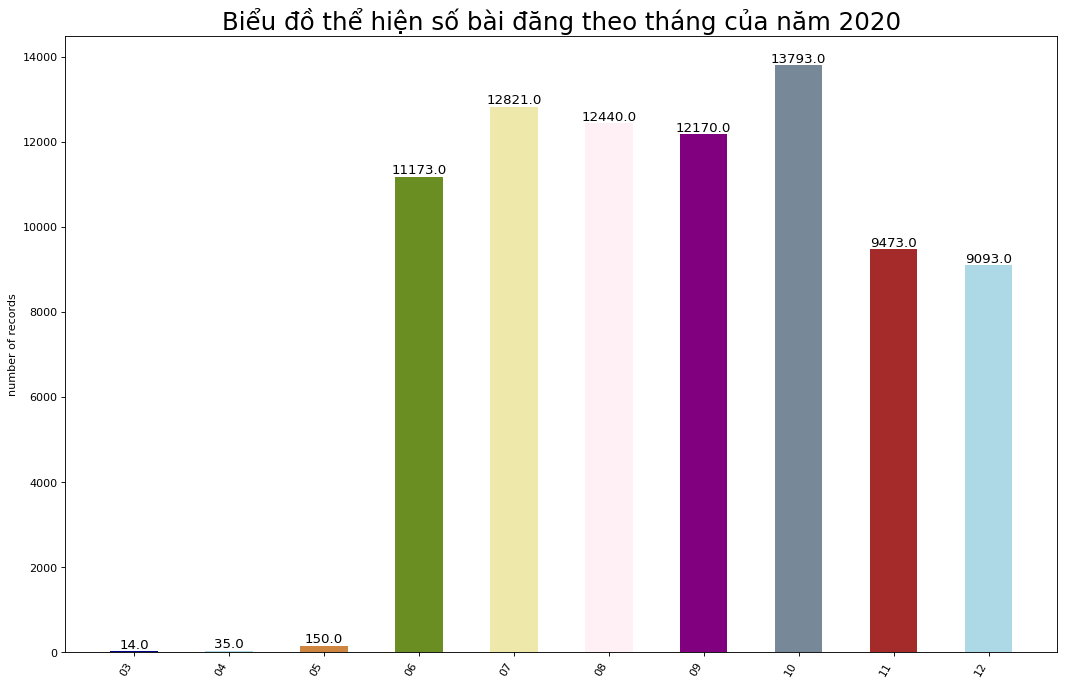

In [22]:
df1 = df.groupby('month').size().reset_index(name='number of records')
n = df1['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number of records'], color=c, width=.5)
for i, val in enumerate(df1['number of records'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment='right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

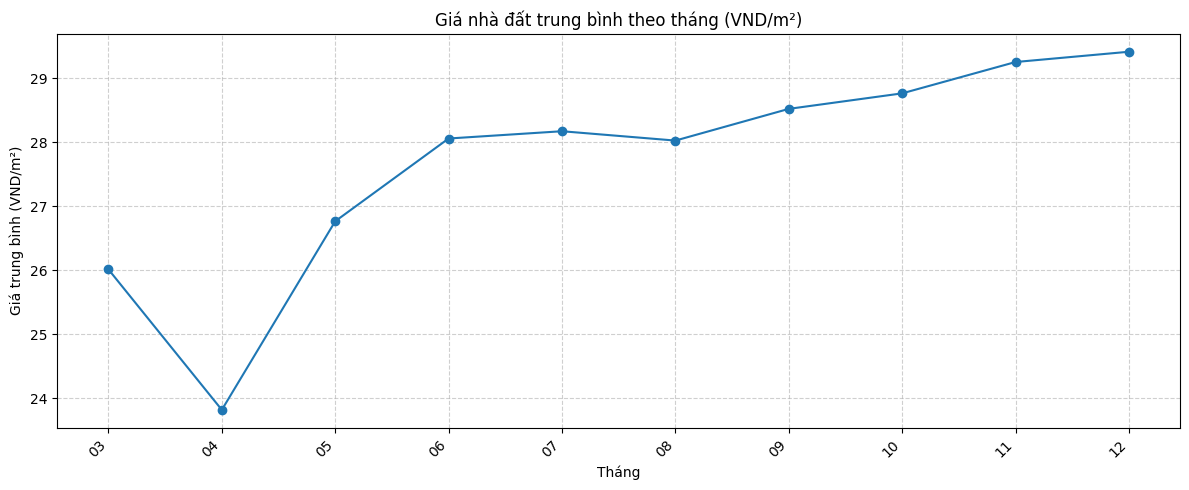

In [24]:
# Nếu chưa có cột price_per_m2, tạo từ price và square
if 'price_per_m2' not in df.columns:
    df['price_per_m2'] = df['price'] / df['square']

# Tính giá trung bình theo tháng
avg_price_month = df.groupby('month')['price_per_m2'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(avg_price_month['month'], avg_price_month['price_per_m2'], marker='o', linestyle='-')
plt.xticks(rotation=45, ha='right')
plt.title("Giá nhà đất trung bình theo tháng (VND/m²)")
plt.ylabel("Giá trung bình (VND/m²)")
plt.xlabel("Tháng")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21828\2841424760.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_apr['price_per_m2'], label='Tháng 4', shade=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_21828\2841424760.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_dec['price_per_m2'], label='Tháng 12', shade=True)


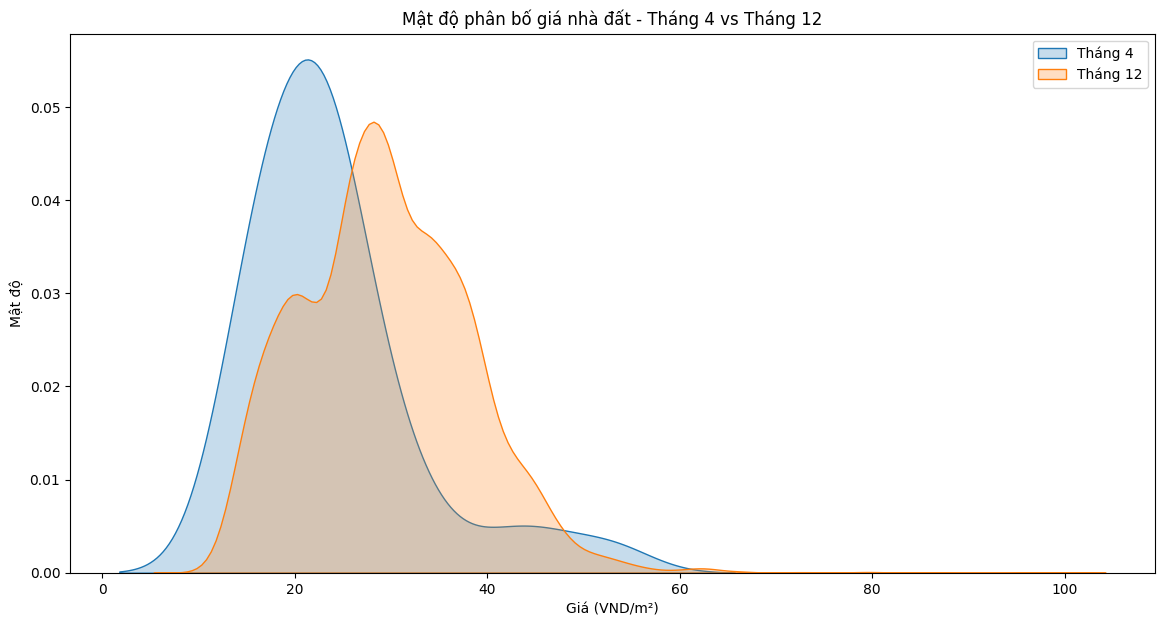

In [33]:
# Lọc dữ liệu tháng 4 và tháng 12 (giả sử cột month dạng "2020-04")
df_apr = df[df['month'] == '04']
df_dec = df[df['month'] == '12']

plt.figure(figsize=(14, 7))
sns.kdeplot(df_apr['price_per_m2'], label='Tháng 4', shade=True)
sns.kdeplot(df_dec['price_per_m2'], label='Tháng 12', shade=True)
plt.title("Mật độ phân bố giá nhà đất - Tháng 4 vs Tháng 12")
plt.xlabel("Giá (VND/m²)")
plt.ylabel("Mật độ")
plt.legend()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21828\2764694691.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dftmp.loc[dftmp['month'] == '12', "price_per_m2"], color="dodgerblue", label="Thang 12", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
C:\Users\Admin\AppData\Local\Temp\ipykernel_21828\2764694691.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.g

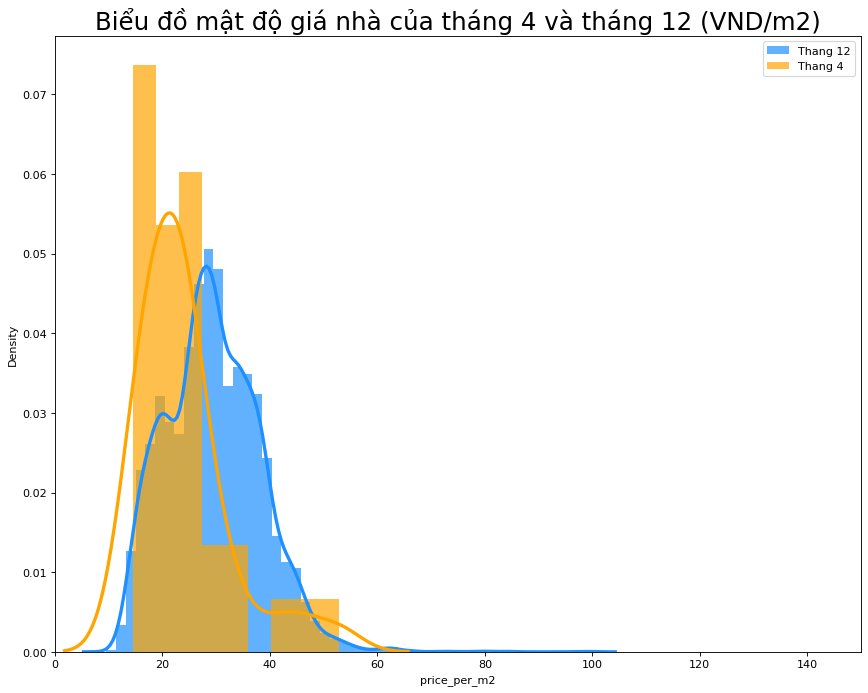

In [39]:
dftmp = df.copy()
plt.figure(figsize=(13,10), dpi= 80)
sns.distplot(dftmp.loc[dftmp['month'] == '12', "price_per_m2"], color="dodgerblue", label="Thang 12", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
sns.distplot(dftmp.loc[dftmp['month'] == '04', "price_per_m2"], color="orange", label="Thang 4", hist_kws={'alpha':.7}, kde_kws={'linewidth': 3})
plt.xlim(0, 150)
plt.title('Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)', fontsize=22)
plt.legend()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21828\2788960539.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df2['month'], rotation=60, horizontalalignment= 'right')


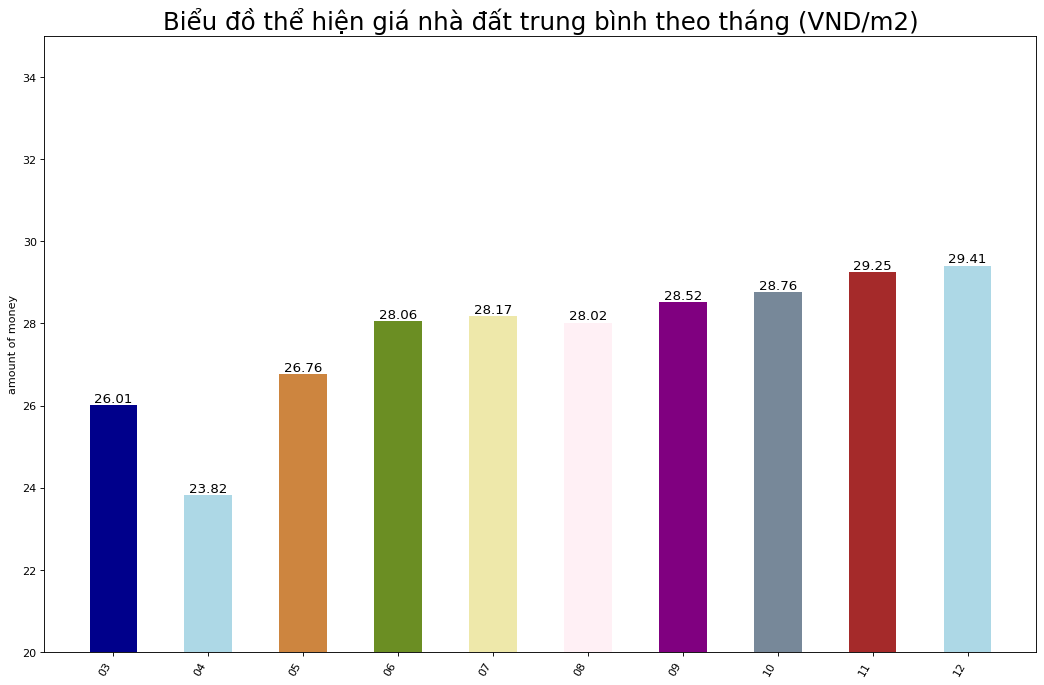

In [37]:
def newprice(row):
    return row['price']/row['square'] #VND/m2
dftmp['pricePerSquare'] = dftmp.apply(newprice, axis = 1)
df2 = dftmp.groupby('month')['pricePerSquare'].mean().reset_index(name='amount of money')
# df2['amount of money'] = df2['amount of money'].apply(lambda x : int(str(x).split('.')[0]))
df2['amount of money'] = df2['amount of money'].apply(lambda x : round(x, 2))
n = df2['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)
plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['month'], df2['amount of money'], color=c, width=.5)
for i, val in enumerate(df2['amount of money'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})
plt.gca().set_xticklabels(df2['month'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo tháng (VND/m2)", fontsize=22)
plt.ylabel('amount of money')
plt.ylim(20,35)
plt.show()

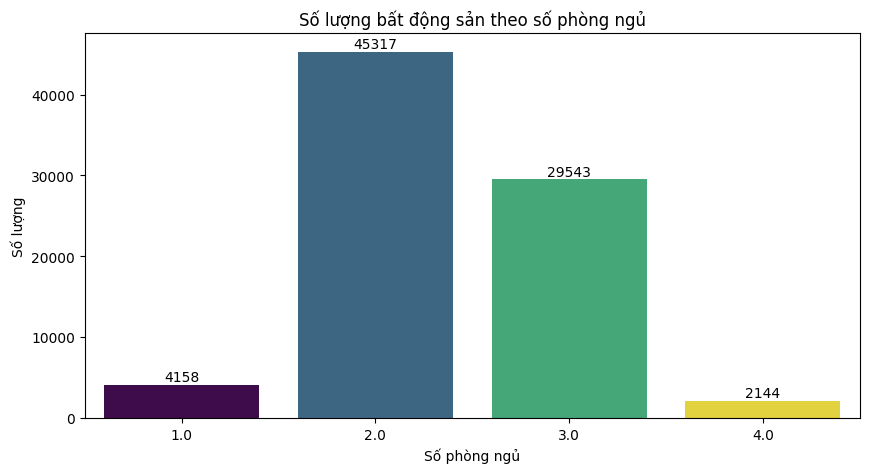

In [44]:
bedroom_counts = df['bedrooms'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=bedroom_counts.index, y=bedroom_counts.values, hue=bedroom_counts.index, palette='viridis', legend=False)
plt.title("Số lượng bất động sản theo số phòng ngủ")
plt.xlabel("Số phòng ngủ")
plt.ylabel("Số lượng")
for i, v in enumerate(bedroom_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')
plt.show()

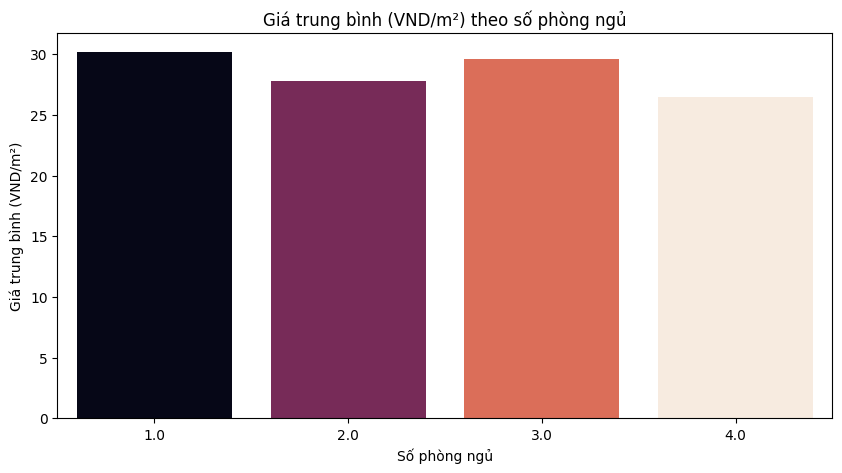

In [46]:
avg_price_bedroom = df.groupby('bedrooms')['price_per_m2'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=avg_price_bedroom, x='bedrooms', y='price_per_m2', hue='bedrooms', palette='rocket', legend=False)
plt.title("Giá trung bình (VND/m²) theo số phòng ngủ")
plt.xlabel("Số phòng ngủ")
plt.ylabel("Giá trung bình (VND/m²)")
plt.show()

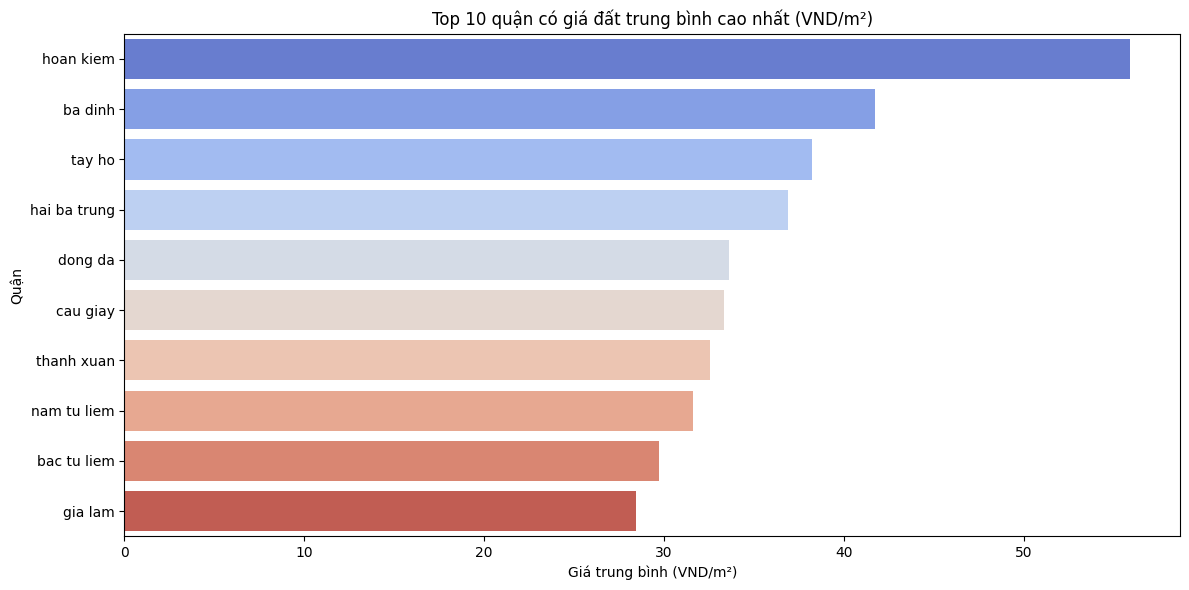

In [47]:
avg_price_district = df.groupby('district')['price_per_m2'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_district.values, y=avg_price_district.index, hue=avg_price_district.index, palette='coolwarm', legend=False)
plt.title("Top 10 quận có giá đất trung bình cao nhất (VND/m²)")
plt.xlabel("Giá trung bình (VND/m²)")
plt.ylabel("Quận")
plt.tight_layout()
plt.show()

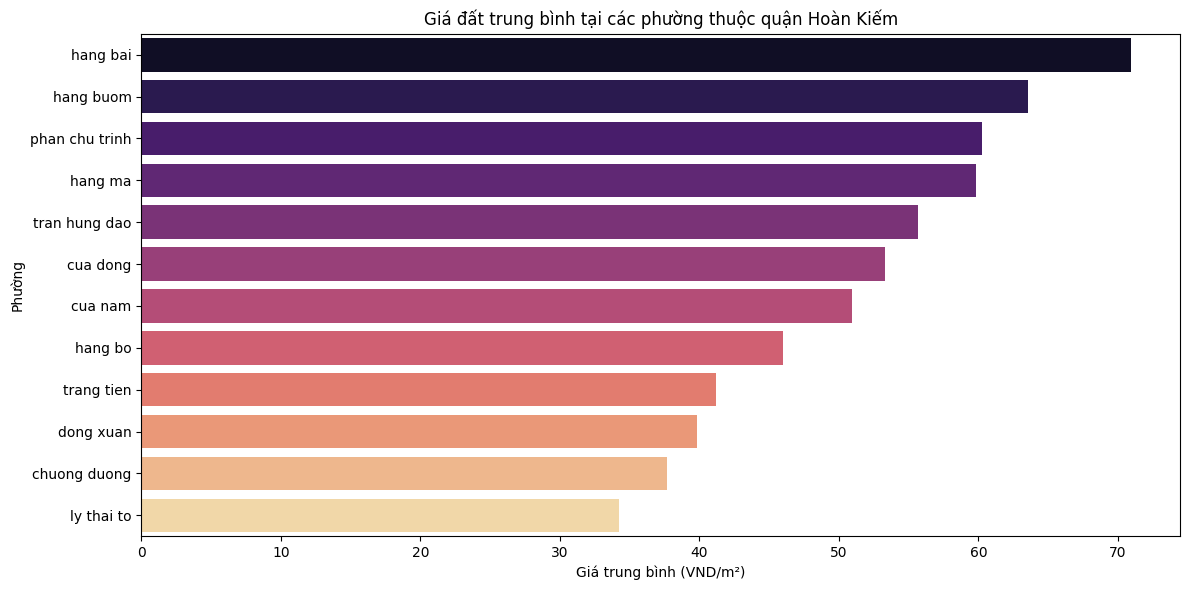

In [49]:
df_hoankiem = df[df['district'] == 'hoan kiem']
avg_price_ward = df_hoankiem.groupby('ward')['price_per_m2'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_ward.values, y=avg_price_ward.index, hue=avg_price_ward.index, palette='magma', legend=False)
plt.title("Giá đất trung bình tại các phường thuộc quận Hoàn Kiếm")
plt.xlabel("Giá trung bình (VND/m²)")
plt.ylabel("Phường")
plt.tight_layout()
plt.show()

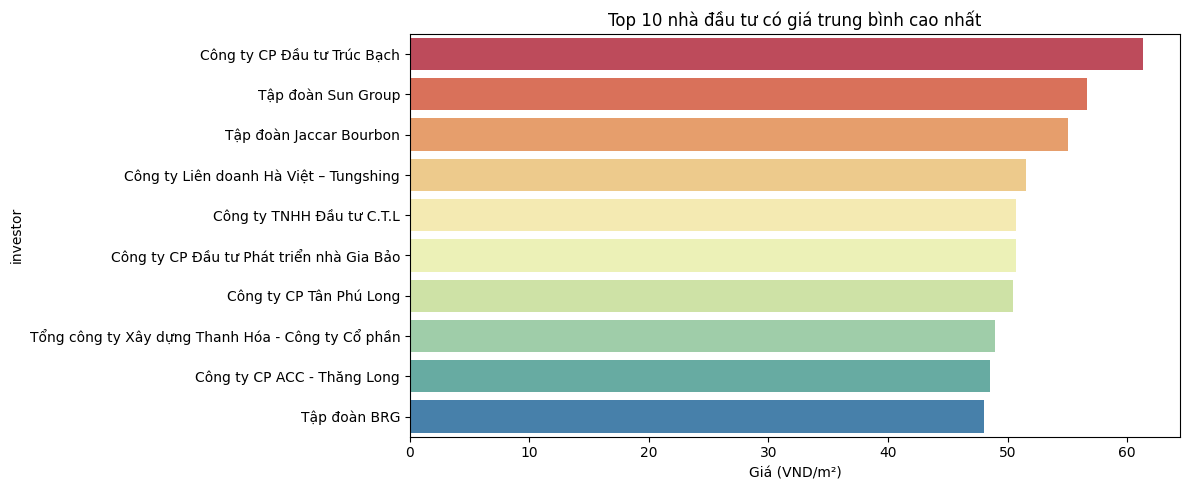

In [52]:
avg_price_investor = df.groupby('investor')['price_per_m2'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=avg_price_investor.values, y=avg_price_investor.index, hue=avg_price_investor.index, palette='Spectral', legend=False)
plt.title("Top 10 nhà đầu tư có giá trung bình cao nhất")
plt.xlabel("Giá (VND/m²)")
plt.tight_layout()
plt.show()

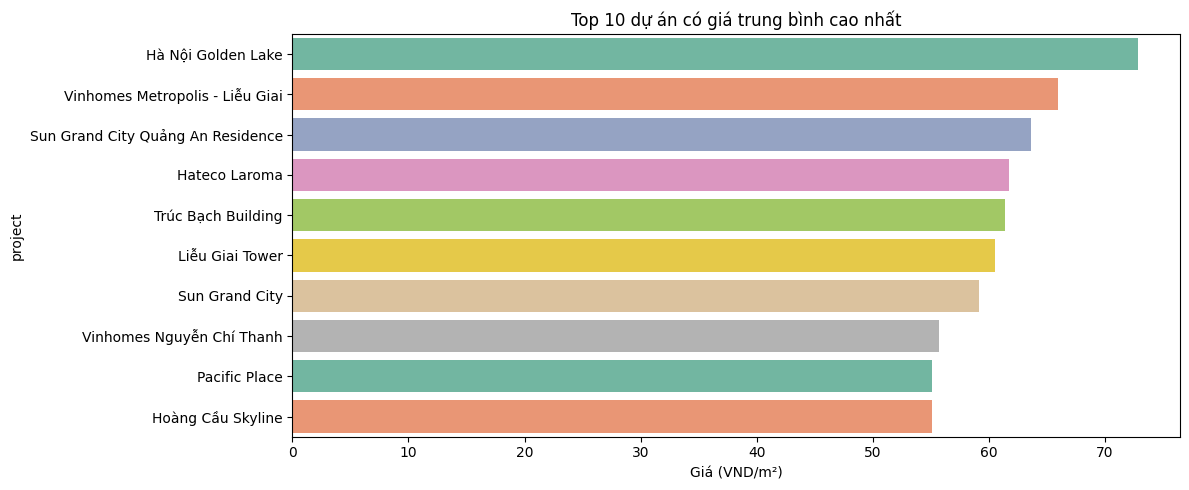

In [53]:
avg_price_project = df.groupby('project')['price_per_m2'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=avg_price_project.values, y=avg_price_project.index, hue=avg_price_project.index, palette='Set2', legend=False)
plt.title("Top 10 dự án có giá trung bình cao nhất")
plt.xlabel("Giá (VND/m²)")
plt.tight_layout()
plt.show()

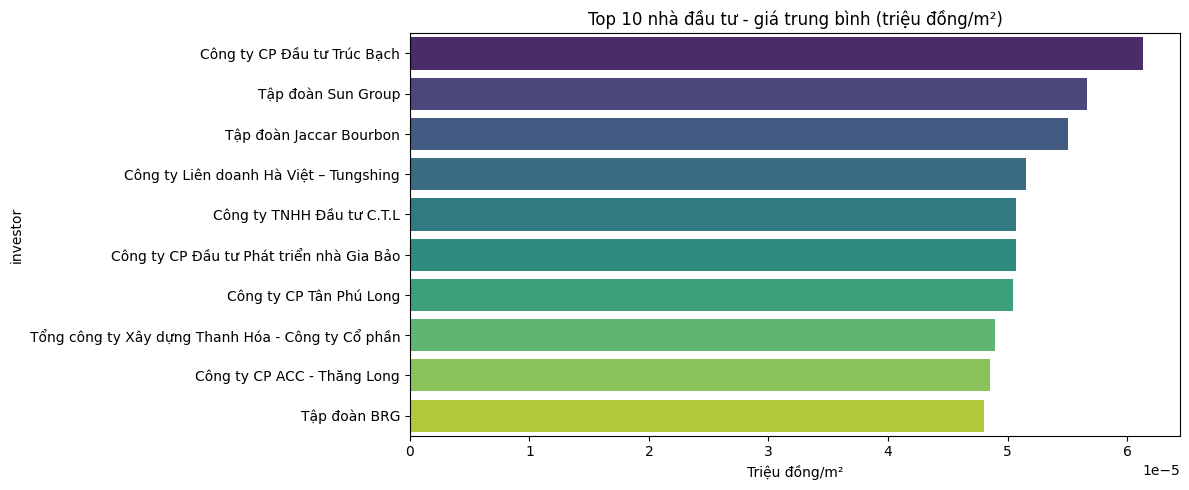

In [54]:
top10_investors = avg_price_investor.head(10) / 1e6
plt.figure(figsize=(12, 5))
sns.barplot(x=top10_investors.values, y=top10_investors.index, hue=top10_investors.index, palette='viridis', legend=False)
plt.title("Top 10 nhà đầu tư - giá trung bình (triệu đồng/m²)")
plt.xlabel("Triệu đồng/m²")
plt.tight_layout()
plt.show()

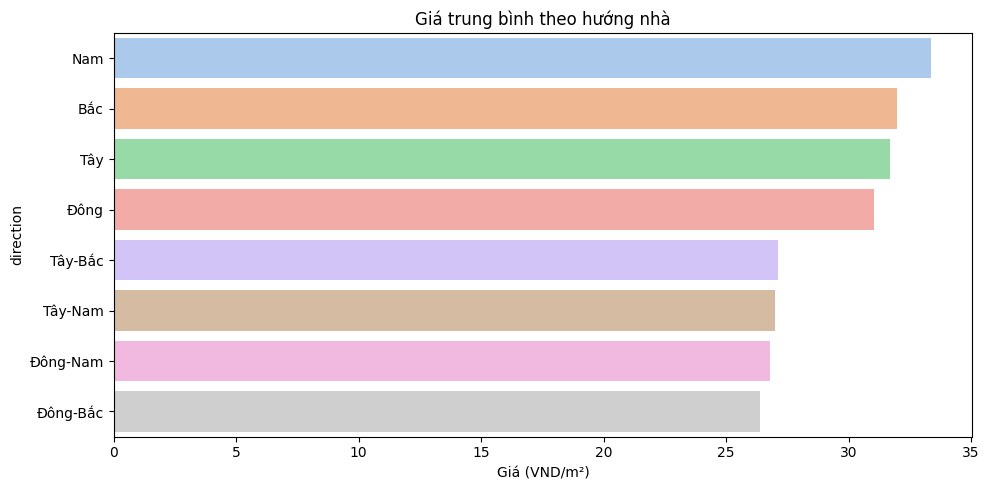

In [55]:
avg_price_direction = df.groupby('direction')['price_per_m2'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price_direction.values, y=avg_price_direction.index, hue=avg_price_direction.index, palette='pastel', legend=False)
plt.title("Giá trung bình theo hướng nhà")
plt.xlabel("Giá (VND/m²)")
plt.tight_layout()
plt.show()

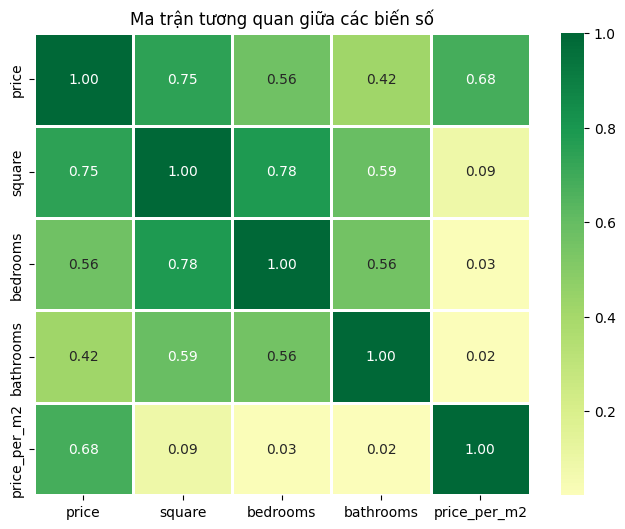

In [56]:
# Chọn các cột số có ý nghĩa
corr_cols = ['price', 'square', 'bedrooms', 'bathrooms', 'price_per_m2']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=1)
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

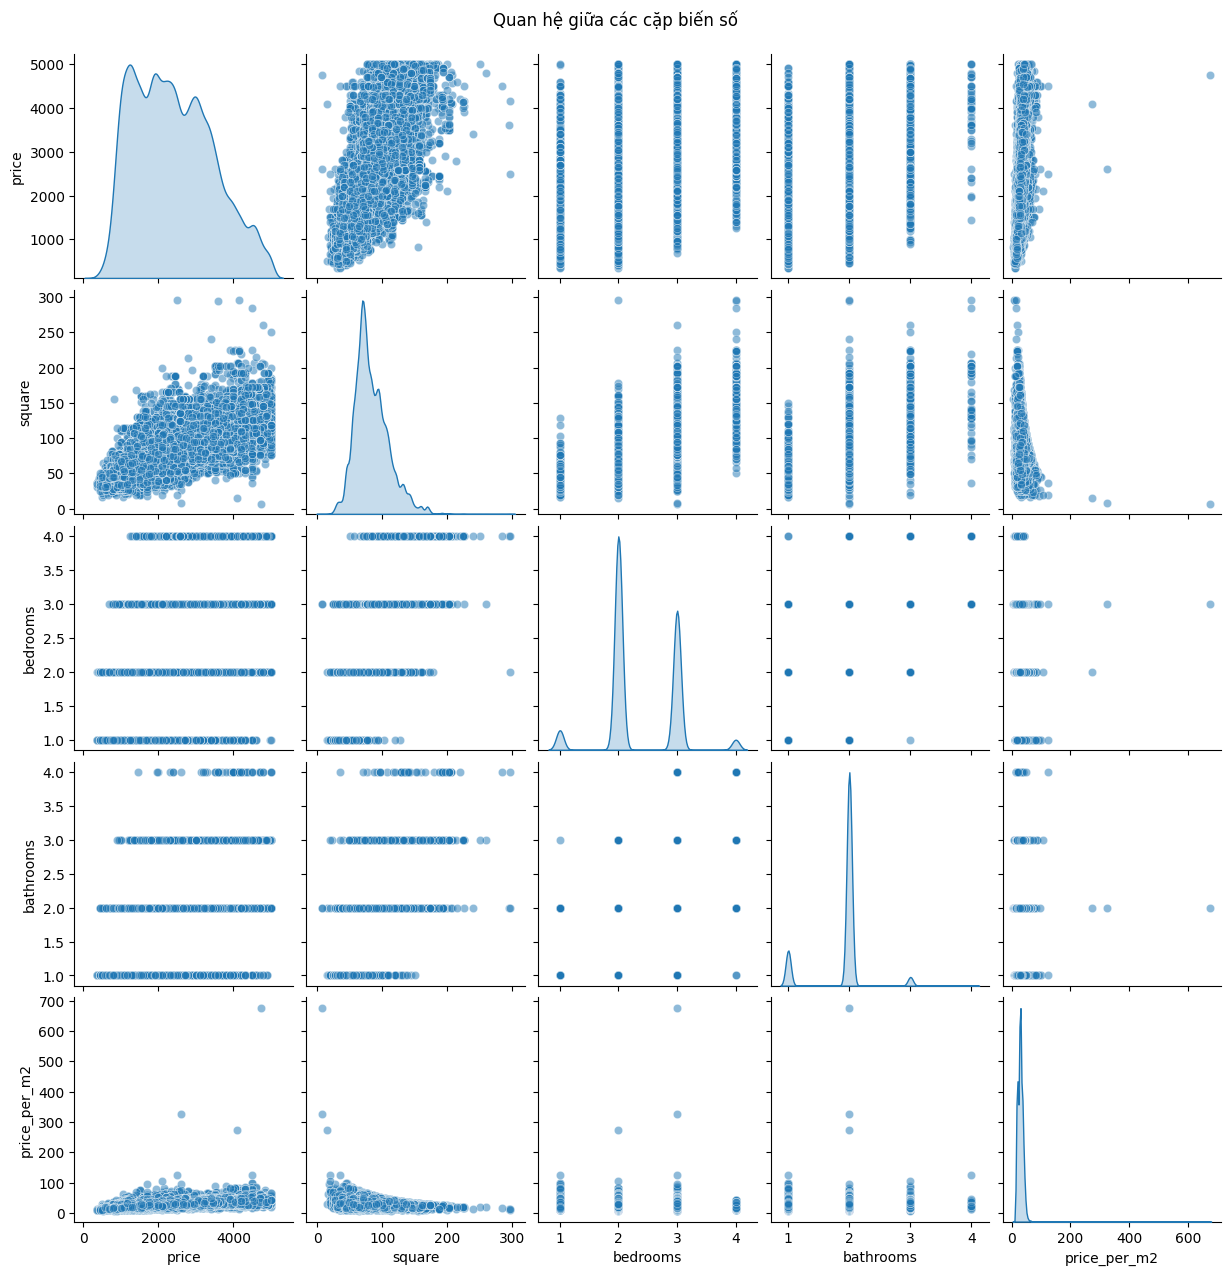

In [57]:
sns.pairplot(df[corr_cols], kind='scatter', diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Quan hệ giữa các cặp biến số", y=1.02)
plt.show()

(0.0, 100.0)

<Figure size 640x480 with 0 Axes>

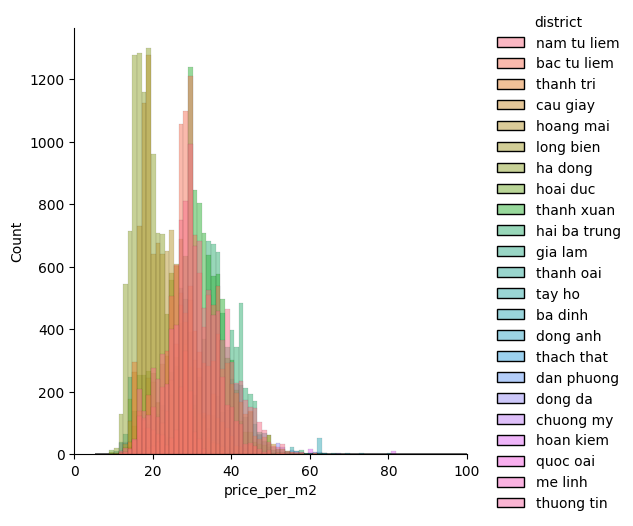

In [60]:
df1 = dftmp.copy()
plt.clf()
sns.displot(df1, x="price_per_m2", hue="district")
plt.xlim(0, 100)